Generowanie danych dla sumy 12-bitowych (50000 próbek)...

--- Rozpoczęcie Treningu ---
Epoch 1/10, Średni błąd MSE: 1.550280
Epoch 2/10, Średni błąd MSE: 0.061803
Epoch 3/10, Średni błąd MSE: 0.061590
Epoch 4/10, Średni błąd MSE: 0.061526
Epoch 5/10, Średni błąd MSE: 0.061495
Epoch 6/10, Średni błąd MSE: 0.061476
Epoch 7/10, Średni błąd MSE: 0.061463
Epoch 8/10, Średni błąd MSE: 0.061454
Epoch 9/10, Średni błąd MSE: 0.061448
Epoch 10/10, Średni błąd MSE: 0.061442
Trening zakończony.

--- Ocena na Zbiorze Testowym ---

Dokładność (poprawna suma) na zbiorze testowym: 93.86% (4693/5000)

--- 5 Przykładowych Wyników ---
   A: [1 0 0 0 0 1 1 1 1 0 0 0 0] (481)
+  B: [1 0 1 0 1 1 0 1 0 1 1 1 0] (3765)
=T (Target): [0 1 1 0 1 0 0 1 0 0 0 0 1] (4246)
=Y (Pred.): [0 1 1 0 1 0 0 1 0 0 0 0 1] (4246) - Surowe: [0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1.]
  WYNIK: OK
----------------------------------------
   A: [1 0 1 0 1 1 1 0 0 0 1 0 0] (1141)
+  B: [1 1 1 1 1 0 0 0 0 1 1 0 0] (1567)
=T (Target): 

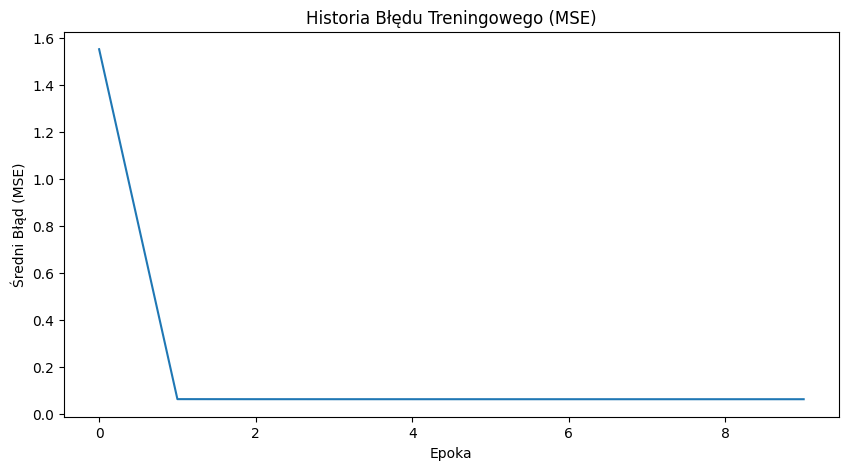

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PARAMETRY HIPERPARAMETRY
# ==============================================================================

# Długość sekwencji
# 12-bit + 1 bit (przeniesienie) = 13
SEQUENCE_LEN = 13 
N_FEATURES = 2      # Wejście: 2 bity (bit_A, bit_B)
N_HIDDEN = 16       # Liczba ukrytych neuronów (do eksperymentowania)
N_OUTPUT = 1        # Wyjście: 1 bit sumy

# Parametry uczenia
LEARNING_RATE = 0.1
N_EXAMPLES = 50000
TRAIN_RATIO = 0.9
N_EPOCHS = 10

# Maksymalna wartość dla 12-bitowej liczby
MAX_VALUE_12BIT = 2**(SEQUENCE_LEN - 1) - 1

# ==============================================================================
# 2. FUNKCJE POMOCNICZE (UTILITY)
# ==============================================================================

def int_to_binary(integer, num_digits):
    """Konwersja liczby całkowitej na odwróconą binarną tablicę o długości num_digits (LSB first)."""
    binary = np.zeros((num_digits, 1))
    for i in range(num_digits):
        binary[i, 0] = integer % 2
        integer //= 2
    return binary

def binary_to_int(binary_array):
    """Konwersja odwróconej tablicy binarnej (LSB first) na liczbę całkowitą."""
    integer = 0
    # Spłaszczenie tablicy, jeśli to konieczne
    flat_array = binary_array.flatten()
    for i, bit in enumerate(flat_array):
        # Sprawdź, czy bit jest bliski 1 (dla zaokrąglonych wyjść RNN)
        if round(bit) == 1:
             integer += 2**i
    return int(integer)

def create_dataset(n_examples, sequence_len):
    """Generuje zestaw danych dla sumy dwóch liczb 12-bitowych."""

    X = np.zeros((n_examples, sequence_len, N_FEATURES))
    T = np.zeros((n_examples, sequence_len, N_OUTPUT))

    for i in range(n_examples):
        # Generowanie dwóch losowych liczby 12-bitowe (0 do 4095)
        a = np.random.randint(MAX_VALUE_12BIT + 1)
        b = np.random.randint(MAX_VALUE_12BIT + 1)
        c = a + b

        # Konwersja na binarne i dopełnianie do SEQUENCE_LEN (13)
        binary_a = int_to_binary(a, sequence_len)
        binary_b = int_to_binary(b, sequence_len)
        binary_c = int_to_binary(c, sequence_len)

        # Tworzenie tensorów wejściowych (X) i docelowych (T)
        X[i, :, 0] = binary_a[:, 0]
        X[i, :, 1] = binary_b[:, 0]
        T[i, :, 0] = binary_c[:, 0]

    return X, T

def print_sample(a_bits, b_bits, t_bits, y_bits):
    """Wyświetla wyniki dla pojedynczej próbki testowej."""
    
    # Sprawdzenie, że Y jest spłaszczony i zaokrąglenie
    t_bits = t_bits.flatten()
    y_bits_raw = y_bits.flatten()
    y_pred_bits = np.round(y_bits_raw).astype(int)

    # Konwersja na liczby całkowite
    a = binary_to_int(a_bits)
    b = binary_to_int(b_bits)
    t = binary_to_int(t_bits)
    y = binary_to_int(y_pred_bits)

    # Wyświetlenie
    print(f'   A: {a_bits.astype(int)} ({a})')
    print(f'+  B: {b_bits.astype(int)} ({b})')
    print(f'=T (Target): {t_bits.astype(int)} ({t})')
    print(f'=Y (Pred.): {y_pred_bits} ({y}) - Surowe: {np.round(y_bits_raw, 2)}')
    
    # Ocena poprawności
    if t == y:
        print('  WYNIK: OK')
    else:
        print('  WYNIK: BŁĄD')

# ==============================================================================
# 3. DEFINICJA I TRENING MODELU RNN
# ==============================================================================

# Funkcje aktywacji
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(output):
    return output * (1 - output)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(output):
    return 1 - output**2

def initialize_parameters(n_features, n_hidden, n_output):
    """Inicjalizacja wag i biasów."""
    
    # Wagi W_hh, W_xh, W_hy są inicjowane losowo w zakresie [-1, 1]
    W_hh = 2 * np.random.rand(n_hidden, n_hidden) - 1
    W_xh = 2 * np.random.rand(n_features, n_hidden) - 1
    W_hy = 2 * np.random.rand(n_hidden, n_output) - 1
    
    b_h = np.zeros((1, n_hidden))
    b_y = np.zeros((1, n_output))
    
    return {'W_hh': W_hh, 'W_xh': W_xh, 'W_hy': W_hy, 'b_h': b_h, 'b_y': b_y}

def forward_pass(X, params, sequence_len):
    """Przebieg w przód (Forward Pass)."""
    W_hh, W_xh, W_hy = params['W_hh'], params['W_xh'], params['W_hy']
    b_h, b_y = params['b_h'], params['b_y']
    
    H = np.zeros((sequence_len, N_HIDDEN)) 
    Y = np.zeros((sequence_len, N_OUTPUT))
    
    h_prev = np.zeros((1, N_HIDDEN))

    for t in range(sequence_len):
        x_t = X[t:t+1, :] # Bieżące wejście (1, N_FEATURES)
        
        # Obliczenie stanu ukrytego
        h_t_input = x_t @ W_xh + h_prev @ W_hh + b_h
        h_t = tanh(h_t_input)
        
        # Obliczenie wyjścia
        y_t_input = h_t @ W_hy + b_y
        y_t = sigmoid(y_t_input)
        
        # Zapisanie stanu i zaktualizowanie h_prev
        H[t, :] = h_t[0, :]
        Y[t, :] = y_t[0, :]
        h_prev = h_t

    return Y, H, h_prev

def backward_pass(X, Y, T, H, params, sequence_len):
    """Propagacja wsteczna w czasie (BPTT)."""
    W_hh, W_xh, W_hy = params['W_hh'], params['W_xh'], params['W_hy']
    
    grads = {
        'W_hh': np.zeros_like(W_hh), 'W_xh': np.zeros_like(W_xh), 
        'W_hy': np.zeros_like(W_hy), 'b_h': np.zeros_like(params['b_h']), 
        'b_y': np.zeros_like(params['b_y'])
    }
    
    # Delta propagowana wstecz z przyszłego kroku czasowego
    delta_h_t_plus_1 = np.zeros_like(params['b_h']) 
    
    # Pętla wstecz
    for t in reversed(range(sequence_len)):
        x_t = X[t:t+1, :] 
        h_t = H[t:t+1, :]
        y_t = Y[t:t+1, :]
        
        # Stan ukryty h_{t-1} lub stan zerowy dla t=0
        h_prev = H[t-1:t] if t > 0 else np.zeros_like(params['b_h'])
        
        # Gradient Warstwy Wyjściowej (Y)
        E_t = (y_t - T[t:t+1, :]) # Błąd MSE
        delta_y = E_t * sigmoid_derivative(y_t)
        
        grads['W_hy'] += h_t.T @ delta_y
        grads['b_y'] += delta_y 
        
        # 2. Gradient Warstwy Ukrytej (H)
        E_h_total = (delta_y @ W_hy.T) + (delta_h_t_plus_1 @ W_hh.T)
        
        delta_h = E_h_total * tanh_derivative(h_t)
        
        # Propagacja błędu do poprzedniego kroku
        delta_h_t_plus_1 = delta_h 

        # Gradienty dla W_xh, W_hh, b_h
        grads['W_xh'] += x_t.T @ delta_h
        grads['W_hh'] += h_prev.T @ delta_h
        grads['b_h'] += delta_h
        
    # Przycinanie gradientów (Climbing)
    for key in grads:
        np.clip(grads[key], -5, 5, out=grads[key])
        
    return grads

def update_parameters(params, grads, learning_rate):
    """Aktualizacja wag za pomocą SGD."""
    for key in params:
        params[key] -= learning_rate * grads[key]
    return params

def train_model(X_train, T_train, params, learning_rate, n_epochs, sequence_len):
    """Główna pętla treningowa."""
    history = []
    
    for epoch in range(n_epochs):
        cost_sum = 0
        
        # Mieszanie danych
        permutation = np.random.permutation(X_train.shape[0])
        X_shuffled = X_train[permutation]
        T_shuffled = T_train[permutation]
        
        for i in range(X_shuffled.shape[0]):
            X_i = X_shuffled[i] 
            T_i = T_shuffled[i] 
            
            # Forward Pass
            Y_i, H_i, _ = forward_pass(X_i, params, sequence_len)
            
            # Obliczenie błędu (MSE)
            cost_sum += np.sum((Y_i - T_i)**2)
            
            # Backward Pass (BPTT)
            grads = backward_pass(X_i, Y_i, T_i, H_i, params, sequence_len)
            
            # Aktualizacja parametrów
            params = update_parameters(params, grads, learning_rate)
            
        avg_cost = cost_sum / X_shuffled.shape[0]
        history.append(avg_cost)
        
        if (epoch + 1) % 1 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}, Średni błąd MSE: {avg_cost:.6f}')

    return params, history

# ==============================================================================
# 4. GŁÓWNA CZĘŚĆ SKRYPTU
# ==============================================================================

if __name__ == '__main__':
    # Generowanie zestawu danych
    print(f"Generowanie danych dla sumy {SEQUENCE_LEN - 1}-bitowych ({N_EXAMPLES} próbek)...")
    X, T = create_dataset(N_EXAMPLES, SEQUENCE_LEN)

    # Podział na zbiór treningowy i testowy
    n_train = int(TRAIN_RATIO * N_EXAMPLES)
    X_train, X_test = X[:n_train], X[n_train:]
    T_train, T_test = T[:n_train], T[n_train:]

    # Inicjalizacja
    params = initialize_parameters(N_FEATURES, N_HIDDEN, N_OUTPUT)

    # Trening
    print("\n--- Rozpoczęcie Treningu ---")
    params, history = train_model(X_train, T_train, params, LEARNING_RATE, N_EPOCHS, SEQUENCE_LEN)
    print("Trening zakończony.")

    # Ocena/Testowanie
    print("\n--- Ocena na Zbiorze Testowym ---")
    
    n_correct = 0
    Y_test_pred = np.zeros_like(T_test)

    for i in range(X_test.shape[0]):
        X_i = X_test[i]
        T_i = T_test[i]
        
        # Przebieg w przód
        Y_i, _, _ = forward_pass(X_i, params, SEQUENCE_LEN)
        Y_test_pred[i] = Y_i
        
        # Porównanie wyników całkowitych
        T_int = binary_to_int(T_i.flatten())
        Y_int = binary_to_int(np.round(Y_i).flatten())
        
        if T_int == Y_int:
            n_correct += 1

    accuracy = n_correct / X_test.shape[0] * 100
    print(f'\nDokładność (poprawna suma) na zbiorze testowym: {accuracy:.2f}% ({n_correct}/{X_test.shape[0]})')

    # Wyświetlenie przykładowych wyników
    print("\n--- 5 Przykładowych Wyników ---")
    for i in range(5): 
        print_sample(X_test[i,:,0], X_test[i,:,1], T_test[i,:,:], Y_test_pred[i])
        print('-' * 40)
        
    # Wykres historii błędu
    plt.figure(figsize=(10, 5))
    plt.plot(history)
    plt.title('Historia Błędu Treningowego (MSE)')
    plt.xlabel('Epoka')
    plt.ylabel('Średni Błąd (MSE)')
    plt.show()